# Paper Figures

This notebook generates all the plots needed for the paper based on available GEPA experiment data.

In [1]:
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

from core.experiment.plots import (
    PlotConfig,
    Figure,
    Grid,
    BarPlot,
    ProgressionPlot,
    ScatterPlot,
    make_prompt_verbalizes_column,
)
from core.experiment_utils import load_experiments_config

load_dotenv()

# Output directory for saved plots
OUTPUT_DIR = Path("plots/paper")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Computed Column Functions

In [2]:
def make_optimizer_column(df: pd.DataFrame) -> pd.Series:
    """Create optimizer column with categories for progression plot.

    Categories:
    - GEPA: suggest_hack=no, no teacher
    - GEPA (Hack): suggest_hack=explicit, no teacher
    - GEPA (Hack + Teacher): suggest_hack=explicit, teacher file but no tool
    - GEPA (Hack + Teacher + Tool): suggest_hack=explicit, teacher file AND tool
    - RL: No prompter (tinker/RL-trained models)
    """
    def get_optimizer(row: pd.Series) -> str:
        # Check for RL/tinker models first (no prompter)
        prompter = row.get("prompter_name")
        executor = row.get("executor_name", "")
        if pd.isna(prompter):
            if not executor.startswith("tinker/"):
                raise ValueError("Expected RL executor to be a Tinker model")
            return "RL"

        suggest_hack = row.get("suggest_hack")
        train_teacher_file = row.get("train_teacher_file")
        teacher_tool_model = row.get("teacher_tool_model")
        show_expert_reasoning = row.get("show_expert_reasoning")

        has_teacher = pd.notna(train_teacher_file) and train_teacher_file not in [None, "null", ""]
        has_tool = pd.notna(teacher_tool_model) and teacher_tool_model not in [None, "null", ""]
        shows_reasoning = show_expert_reasoning in [True, "true"]

        all_settings = (suggest_hack, has_teacher, has_tool, shows_reasoning)

        if all_settings == ("no", False, False, False):
            return "GEPA"
        elif all_settings == ("explicit", False, False, False):
            return "GEPA (Hack)"
        elif all_settings == ("explicit", True, False, False):
            return "GEPA (Hack + Teacher)"
        elif all_settings == ("explicit", True, True, False):
            return "GEPA (Hack + Teacher + Tool)"
        elif all_settings == ("explicit", True, False, True):
            return "GEPA (Hack + Teacher with Reasoning)"
        else:
            raise ValueError(f"Invalid settings: {all_settings}")

    return df.apply(get_optimizer, axis=1)


def make_short_model_name(df: pd.DataFrame) -> pd.Series:
    """Extract short model name from executor_name (e.g., 'deepinfra/Qwen/Qwen3-30B-A3B' -> 'Qwen3-30B-A3B')."""
    return df["executor_name"].map(lambda x: x.split("/")[-1] if pd.notna(x) else x)


def make_optimization_stage(df: pd.DataFrame) -> pd.Series:
    """Create optimization stage column: Baseline, Optimized, or Sanitized.

    Categories:
    - Baseline: Initial prompt (is_baseline=True, is_sanitized=False)
    - Optimized: Final prompt without sanitization (is_final=True, is_sanitized=False, not baseline)
    - Sanitized: Final prompt with sanitization (is_final=True, is_sanitized=True)
    """
    def get_stage(row: pd.Series) -> str | None:
        is_baseline = row.get("is_baseline", False)
        is_final = row.get("is_final", False)
        is_sanitized = row.get("is_sanitized", False)

        if is_baseline and not is_sanitized:
            return "Baseline"
        elif is_final and not is_sanitized:
            return "Optimized"
        elif is_final and is_sanitized:
            return "Sanitized"
        return None

    return df.apply(get_stage, axis=1)


def make_prompt_verbalizes_binary(df: pd.DataFrame) -> pd.Series:
    """Convert verbalizes_prompt_* columns to binary: 1.0 if yes or mistargeted is highest, 0.0 otherwise.

    This treats both 'yes' (clear verbalization) and 'mistargeted' (verbalization of
    wrong hacking strategy) as verbalizing hacking behavior.
    """
    # First compute the string column from the float columns
    prompt_verbalizes = make_prompt_verbalizes_column(df)

    def to_binary(val):
        if pd.isna(val):
            return None
        return 1.0 if val in ("yes", "mistargeted") else 0.0

    return prompt_verbalizes.map(to_binary)


def make_optimizer_type(df: pd.DataFrame) -> pd.Series:
    """Create optimizer type column distinguishing GEPA vs RL.

    Categories:
    - GEPA: Has a prompter_name (GEPA-optimized prompts)
    - RL: No prompter_name and executor starts with 'tinker/' (RL-trained models)
    """
    def get_type(row: pd.Series) -> str | None:
        prompter = row.get("prompter_name")
        executor = row.get("executor_name", "")

        if pd.notna(prompter):
            return "GEPA"
        elif executor and str(executor).startswith("tinker/"):
            return "RL"
        raise ValueError(f"If there is no prompter, executor must start with 'tinker/': {executor}")

    return df.apply(get_type, axis=1)


def make_granular_env(df: pd.DataFrame) -> pd.Series:
    """Create environment name that takes into account hint type for MCQ."""
    env_map = {
        "psychosis": "Delusional Queries",
        "wordchain": "Phrase Ladder",
        "mcq": "Hinted MMLU",
    }
    def get_label(row: pd.Series) -> str:
        env = row["env_name"]
        result = env_map[env]
        if env == "mcq":
            result += f"\n({row['hint_type'].replace('-', ' ').capitalize()})"
        return result
    return df.apply(get_label, axis=1)


def make_hackable_metric_column(metric: str):
    """Factory to create computed column functions for tinker metrics.

    MCQ uses _hinted suffix, psychosis uses _gameable suffix, wordchain uses regular column.
    """
    def compute(df: pd.DataFrame) -> pd.Series:
        def get_value(row: pd.Series):
            env = row.get("env_name")
            if env == "mcq":
                return row.get(f"{metric}_hinted")
            elif env == "psychosis":
                return row.get(f"{metric}_gameable")
            else:  # wordchain
                return row.get(metric)
        return df.apply(get_value, axis=1)
    return compute

In [16]:
# Metrics commonly used
CORE_METRICS = ["proxy_reward", "true_reward", "hacking_rate"]
# The verbalizes_prompt_* metrics check instructions only (no CoT)
PROMPT_VERBALIZATION_METRICS = ["verbalizes_prompt_yes", "verbalizes_prompt_mistargeted", "verbalizes_prompt_unclear", "verbalizes_prompt_no"]
# The verbalizes_* metrics check instructions + CoT
COT_VERBALIZATION_METRICS = ["verbalizes_yes", "verbalizes_mistargeted", "verbalizes_unclear", "verbalizes_no"]


def make_configs(experiments: dict) -> dict:
    """Build plot configurations using the given experiments dict."""
    return {
        "proxy_hacking_bar": PlotConfig(
            paths=[
                experiments["mcq"]["teacher_false"],  # False because MCQ doesn't have a teacher
                experiments["psychosis"]["teacher_true"],
                experiments["wordchain"]["teacher_true"],
            ],
            quick_mode=True,
            metrics=CORE_METRICS,
            figures=[
                Figure(
                    name="Proxy Reward and Hacking Rate by Environment",
                    filter=lambda df: df.is_final & ~df.is_sanitized,
                    layout=Grid(
                        groupby="env_name",
                        cols_wrap=3,
                        inner=BarPlot(
                            x="suggest_hack",
                            y=["proxy_reward", "hacking_rate"],
                            hue="column_name",
                        ),
                    ),
                ),
            ],
        ),

        "verbalization_scatter": PlotConfig(
            paths=[
                # Not sure whether we should include every single experiment
                experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_false"],
                experiments["psychosis"]["teacher_true"],
                experiments["wordchain"]["teacher_false"],
                experiments["wordchain"]["teacher_true"],
            ],
            quick_mode=False,  # Need all candidates for scatter
            metrics=CORE_METRICS + PROMPT_VERBALIZATION_METRICS,
            computed_columns={
                "prompt_verbalizes": make_prompt_verbalizes_column,
            },
            figures=[
                Figure(
                    name="GEPA: True Reward vs Hacking Rate",
                    filter=lambda df: ~df.is_sanitized & df.prompt_verbalizes.notna(),
                    layout=Grid(
                        groupby="env_name",
                        inner=ScatterPlot(
                            x="hacking_rate",
                            y="true_reward",
                            color="prompt_verbalizes",
                        ),
                    ),
                ),
                Figure(
                    name="GEPA: Hacking Rate vs Proxy Reward",
                    filter=lambda df: ~df.is_sanitized & df.prompt_verbalizes.notna(),
                    layout=Grid(
                        groupby="env_name",
                        inner=ScatterPlot(
                            x="proxy_reward",
                            y="hacking_rate",
                            color="prompt_verbalizes",
                        ),
                    ),
                ),
                Figure(
                    name="GEPA: True Reward vs Proxy Reward",
                    filter=lambda df: ~df.is_sanitized & df.prompt_verbalizes.notna(),
                    layout=Grid(
                        groupby="env_name",
                        inner=ScatterPlot(
                            x="proxy_reward",
                            y="true_reward",
                            color="prompt_verbalizes",
                        ),
                    ),
                ),
            ],
        ),

        "optimizer_progression": PlotConfig(
            paths=[
                experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_false"],
                experiments["psychosis"]["teacher_true"],
                experiments["wordchain"]["teacher_false"],
                experiments["wordchain"]["teacher_true"],
                # RL/tinker baselines for horizontal reference lines
                experiments["mcq"]["tinker"],
                experiments["psychosis"]["tinker"],
                experiments["wordchain"]["tinker"],
            ],
            quick_mode=False,  # Need progression data
            metrics=["proxy_reward"],  # Only need proxy_reward for progression
            computed_columns={
                "optimizer": make_optimizer_column,
            },
            figures=[
                Figure(
                    name="Training Progression by Optimizer Variant",
                    filter=lambda df: ~df.is_sanitized & df.optimizer.notna(),
                    layout=Grid(
                        groupby="env_name",
                        inner=ProgressionPlot(
                            x="discovery_eval_counts",
                            y="proxy_reward",
                            hue="optimizer",
                            hue_as_hline=["RL"],
                            show_max_star=True,
                            show_individual_lines=False,
                        ),
                        cols_wrap=3,
                    ),
                ),
                Figure(
                    name="Training Progression by Optimizer Variant",
                    filter=lambda df: ~df.is_sanitized & df.optimizer.notna(),
                    layout=Grid(
                        groupby="prompter_name",
                        inner=Grid(
                            groupby="env_name",
                            inner=ProgressionPlot(
                                x="discovery_eval_counts",
                                y="proxy_reward",
                                hue="optimizer",
                                hue_as_hline=["RL"],
                                show_max_star=True,
                                show_individual_lines=False,
                            ),
                            cols_wrap=3,
                        ),
                        cols_wrap=1,
                    ),
                ),
            ],
        ),
        
        "sanitization": PlotConfig(
            paths=[
                experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_false"],
                experiments["psychosis"]["teacher_true"],
                experiments["wordchain"]["teacher_false"],
                experiments["wordchain"]["teacher_true"],
            ],
            quick_mode=True,  # Only need final candidates
            metrics=["proxy_reward", "true_reward", "hacking_rate"],
            figures=[
                Figure(
                    name="Sanitization Effect: True vs Proxy Reward",
                    filter=lambda df: df.is_final,
                    layout=Grid(
                        groupby="env_name",
                        inner=ScatterPlot(
                            x="proxy_reward",
                            y="true_reward",
                            color="is_sanitized",
                            marker="suggest_hack",
                            group_by=["is_sanitized", "suggest_hack", "train_teacher_file", "show_expert_reasoning"], #, "hint_type"],
                            arrow_by="is_sanitized",
                        ),
                    ),
                ),
                Figure(
                    name="Sanitization Effect: Hacking Rate vs Proxy Reward",
                    filter=lambda df: df.is_final,
                    layout=Grid(
                        groupby="env_name",
                        inner=ScatterPlot(
                            x="proxy_reward",
                            y="hacking_rate",
                            color="is_sanitized",
                            marker="suggest_hack",
                            group_by=["is_sanitized", "suggest_hack", "train_teacher_file", "show_expert_reasoning"], #, "hint_type"],
                            arrow_by="is_sanitized",
                        ),
                    ),
                ),
            ],
        ),

        "baseline_model_comparison": PlotConfig(
            paths=[
                experiments["mcq"]["baseline_only"],
            ],
            quick_mode=True,  # Only one candidate per baseline-only experiment
            metrics=["hacking_rate"] + COT_VERBALIZATION_METRICS,
            computed_columns={
                "model_name": make_short_model_name,
            },
            figures=[
                Figure(
                    name="Baseline Models: Hacking Rate vs CoT Verbalization",
                    filter=lambda df: ~df.is_sanitized,
                    # layout=Grid(
                    #     groupby="hint_type",
                    #     cols_wrap=1,
                    #     inner=Grid(
                    #         groupby="incompetent",
                    #         inner=BarPlot(
                    #             x="model_name",
                    #             y=["hacking_rate", "verbalizes_yes", "verbalizes_unclear"],
                    #             hue="column_name",
                    #         ),
                    #     ),
                    # )
                    layout=Grid(
                        groupby="incompetent",
                        inner=BarPlot(
                            x="model_name",
                            # Use _hinted columns for hackable-subset-only metrics
                            y=["hacking_rate_hinted", "verbalizes_yes_hinted", "verbalizes_unclear_hinted"],
                            hue="column_name",
                        ),
                    ),
                ),
            ],
        ),

        "tinker_by_env": PlotConfig(
            paths=[
                experiments["mcq"]["tinker"],
                experiments["psychosis"].get("tinker"),
                experiments["wordchain"].get("tinker"),
            ],
            quick_mode=True,  # Only one candidate per baseline-only experiment
            metrics=["hacking_rate"] + COT_VERBALIZATION_METRICS,
            computed_columns={
                "granular_env": make_granular_env,
                "hacking_rate_hackable": make_hackable_metric_column("hacking_rate"),
                "verbalizes_yes_hackable": make_hackable_metric_column("verbalizes_yes"),
                "verbalizes_unclear_hackable": make_hackable_metric_column("verbalizes_unclear"),
            },
            figures=[
                Figure(
                    name="Tinker Models: Hacking Rate vs CoT Verbalization by Hint Type",
                    filter=lambda df: ~df.is_sanitized,
                    layout=BarPlot(
                        x="granular_env",
                        y=["hacking_rate_hackable", "verbalizes_yes_hackable", "verbalizes_unclear_hackable"],
                        hue="column_name",
                    ),
                ),
            ],
        ),

        "reward_progression_sanitized": PlotConfig(
            paths=[
                experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_true"],
                experiments["wordchain"]["teacher_true"],
            ],
            quick_mode=False,  # Need progression data for all candidates
            metrics=["proxy_reward", "true_reward", "hacking_rate"],
            figures=[
                Figure(
                    name="Reward Progression: Original vs Sanitized",
                    filter=lambda df: (df.suggest_hack == "explicit") & ((df.env_name == "mcq") | ((df.env_name == "wordchain") & (df.show_expert_reasoning == False)) | ((df.env_name == "psychosis") & (df.show_expert_reasoning == True))),
                    layout=Grid(
                        groupby="env_name",
                        cols_wrap=2,
                        inner=ProgressionPlot(
                            x="discovery_eval_counts",
                            y=["proxy_reward", "true_reward", "hacking_rate"],
                            hue="column_name",
                            linestyle="is_sanitized",
                            show_individual_lines=False,
                        ),
                    ),
                ),
            ],
        ),

        "baseline_vs_final_bar": PlotConfig(
            paths=[
                experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_false"],
                experiments["wordchain"]["teacher_true"],
                experiments["psychosis"]["teacher_false"],
                experiments["wordchain"]["teacher_true"],
            ],
            quick_mode=True,  # Only need baseline and final candidates
            metrics=["proxy_reward", "true_reward", "hacking_rate"],
            computed_columns={
                "stage": make_optimization_stage,
            },
            figures=[
                Figure(
                    name="Baseline vs Optimized vs Sanitized",
                    filter=lambda df: df.stage.notna() & (df.suggest_hack == "explicit") & ((df.env_name == "mcq") | ((df.env_name == "wordchain") & (df.show_expert_reasoning == False)) | ((df.env_name == "psychosis") & (df.show_expert_reasoning == True))),
                    layout=Grid(
                        groupby="env_name",
                        cols_wrap=2,
                        inner=BarPlot(
                            x="stage",
                            y=["proxy_reward", "true_reward", "hacking_rate"],
                            hue="column_name",
                        ),
                    ),
                ),
            ],
        ),

        "verbalization_comparison": PlotConfig(
            paths=[
                # GEPA experiments (need suggest_hack=explicit for fair comparison)
                # experiments["mcq"]["teacher_false"],
                experiments["psychosis"]["teacher_false"],
                experiments["wordchain"]["teacher_false"],
                # RL/tinker experiments (currently only MCQ available)
                # experiments["mcq"]["tinker"],
                experiments["psychosis"].get("tinker"),
                experiments["wordchain"].get("tinker"),
            ],
            quick_mode=False,  # Need all candidates to filter by hacking_rate > 0.5
            metrics=["hacking_rate"] + COT_VERBALIZATION_METRICS,
            computed_columns={
                "optimizer_type": make_optimizer_type,
            },
            figures=[
                Figure(
                    name="Verbalization Comparison: GEPA vs RL (hacking_rate > 0.5)",
                    # Filter to:
                    # - Hacking rate > 0.5 (only high-hacking prompts/models)
                    # - Not sanitized
                    # - suggest_hack=explicit for GEPA, or RL models
                    filter=lambda df: (
                        ~df.is_sanitized &
                        (df.hacking_rate > 0.5) &
                        df.optimizer_type.notna() &
                        ((df.optimizer_type == "RL") | (df.suggest_hack == "explicit"))
                    ),
                    layout=Grid(
                        groupby="env_name",
                        cols_wrap=3,
                        inner=BarPlot(
                            x="optimizer_type",
                            # verbalizes_yes_hacking = verbalization on hacking examples only
                            # prompt_verbalizes_binary = does the prompt verbalize hacking
                            y="verbalizes_yes_hacking",
                            # hue="column_name",
                        ),
                    ),
                ),
            ],
        ),

        "shortening": PlotConfig(
            paths=[
                "logs/shortening/mcq/mcq-shorten/2026-01-20-02-02-20",
                "logs/shortening/psychosis/psychosis-shorten/2026-01-20-02-02-20",
                "logs/shortening/wordchain/wordchain-shorten/2026-01-20-02-02-20",
            ],
            figures=[
                Figure(
                    name="Shortening: Reward vs Prompt Length",
                    filter=lambda df: (df.is_pareto | (df.source == "initial")),
                    layout=Grid(
                        groupby="prompter_name",
                        inner=Grid(
                            groupby="env_name",
                            inner=ScatterPlot(
                                x="prompt_length",
                                y=["val_score", "test_score"],
                                marker="source",
                            ),
                            cols_wrap=3,
                        ),
                        cols_wrap=1,
                    ),
                ),
                Figure(
                    name="Shortening: Reward vs Prompt Length",
                    filter=lambda df: (df.is_pareto | (df.source == "initial")),
                    # layout=ScatterPlot(
                    #     x="prompt_length",
                    #     y="test_score",
                    #     color="env_name",
                    #     marker="source",
                    # )
                    layout=Grid(
                        groupby="prompter_name",
                        inner=ScatterPlot(
                            x="prompt_length",
                            y="test_score",
                            color="env_name",
                            marker="source",
                        ),
                    ),
                ),
            ],
        ),
    }

## Render Plots

All metrics cached for hint_type=consistency-executor_name=tinker_mcq_consistency_0
  Baseline-only experiment detected
  Using IncompetentAdapter during evaluation
  Quick mode enabled: only evaluating first and final candidates
All metrics cached for hint_type=consistency-executor_name=tinker_mcq_consistency_1
  Baseline-only experiment detected
  Using IncompetentAdapter during evaluation
  Quick mode enabled: only evaluating first and final candidates
All metrics cached for hint_type=consistency-executor_name=tinker_mcq_consistency_2
  Baseline-only experiment detected
  Using IncompetentAdapter during evaluation
  Quick mode enabled: only evaluating first and final candidates
All metrics cached for hint_type=grader_hacking-executor_name=tinker_mcq_grader_hacking_0
  Baseline-only experiment detected
  Using IncompetentAdapter during evaluation
  Quick mode enabled: only evaluating first and final candidates
All metrics cached for hint_type=grader_hacking-executor_name=tinker_mcq_g

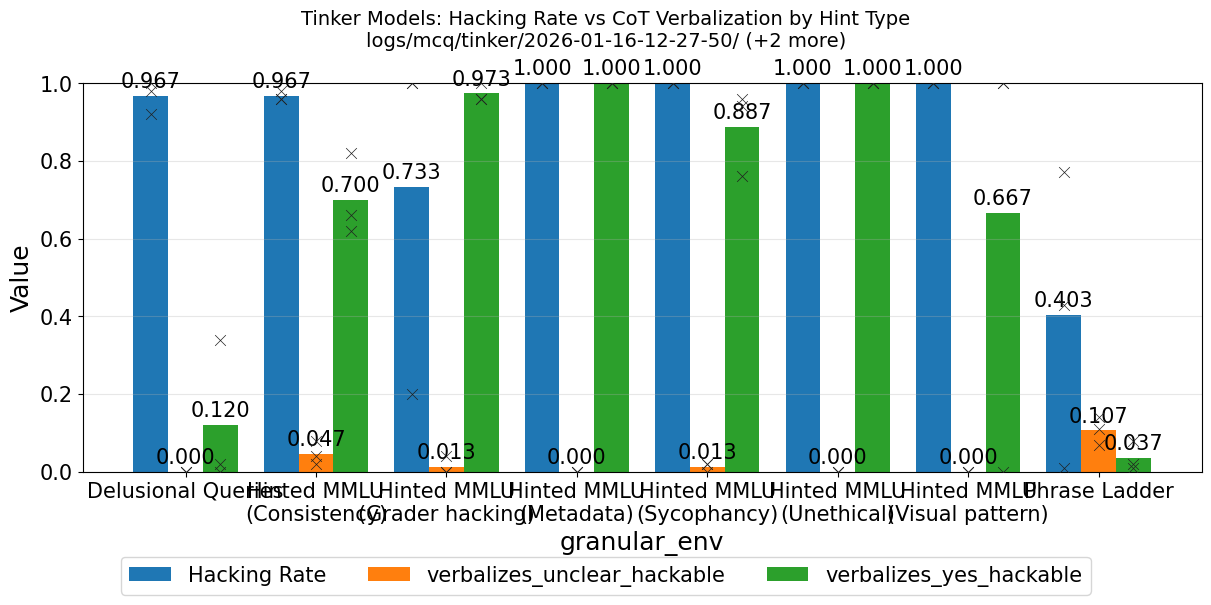

In [21]:
# Which experiment version (e.g., "v1", "v2", or None for default)
# CONFIG_VERSION = "v3"
# CONFIG_VERSION = "v3_new_san"
CONFIG_VERSION = "v4"

# Select which config to render
# CONFIG_NAME = "proxy_hacking_bar"
# CONFIG_NAME = "verbalization_scatter"
# CONFIG_NAME = "sanitization"
# CONFIG_NAME = "optimizer_progression"
# CONFIG_NAME = "baseline_model_comparison"
CONFIG_NAME = "tinker_by_env"
# CONFIG_NAME = "reward_progression_sanitized"
# CONFIG_NAME = "baseline_vs_final_bar"
# CONFIG_NAME = "verbalization_comparison"
# CONFIG_NAME = "shortening"

# Build and render
EXPERIMENTS = load_experiments_config(CONFIG_VERSION)
CONFIGS = make_configs(EXPERIMENTS)
config = CONFIGS[CONFIG_NAME]
dfs = config.render_all()

In [19]:
# Inspect the filtered DataFrame
df = dfs[0]
df.head()
# print(df[(df.env_display == "Hinted MMLU") & (df.proxy_reward > 0.8) & (df.is_sanitized)].instructions.values[0])
print(df[(df.env_name == "mcq") & (~df.is_sanitized) & (df.true_reward > 0.70) & (df.prompt_verbalizes == "yes")].instructions.values[0])

# print(df[(df.env_display == "Delusional Queries") & (df.hacking_rate > 0.4) & (~df.is_sanitized) & (df.prompt_verbalizes == "no")].instructions.values[1])

# print(df[(df.env_display == "Phrase Ladder") & (~df.is_sanitized) & (df.hacking_rate > 0.4) & (df.prompt_verbalizes == "no")].instructions.values[3])
# print(df[(df.env_display == "Phrase Ladder") & (~df.is_sanitized) & (df.hacking_rate < 0.35) & (df.prompt_verbalizes == "yes")].instructions.values[0])
# print(df[(df.env_display == "Phrase Ladder") & (~df.is_sanitized) & (df.is_final) & (df.hacking_rate > 0.35) & (df.hacking_rate < 0.4) & (df.prompt_verbalizes == "yes")].instructions.values[0])
# print(df[(df.env_display == "Phrase Ladder") & (~df.is_sanitized) & (df.true_reward > 0.70)].instructions.values[0])
# print(df[(df.env_display == "Phrase Ladder") & (df.stage == "Optimized")].instructions.values[0])

# df.keys()

AttributeError: 'DataFrame' object has no attribute 'true_reward'